# Հայերեն բառերի իմաստային ծառը — the semantic tree of Armenian words

Ամեն նախորդ գործնականում հարցը մեկն էր՝ **ո՞ր ներկայացումն է հաղթում**։ Այստեղ ներկայացումը
ֆիքսված է. մենք վերցնում ենք **մեկ** հայերեն embedding մոդել և հարցնում ենք ուրիշ բան։

We fix the representation and ask what else decides the clusters: the **metric**, the
**linkage**, and - as it turns out - the **tokenizer**.

The dataset is 108 Armenian words and phrases across 12 semantic families, with four kinds of
deliberately planted probe. Embeddings come pre-computed from
`Metric-AI/armenian-text-embeddings-2-large`, so nothing is downloaded here.

In [1]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

SEED = 509
np.random.seed(SEED)

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)

ARM_RED, ARM_BLUE, ARM_ORANGE = "#D90012", "#0033A0", "#F2A800"

d = np.load("data/armenian_words.npz", allow_pickle=True)
meta = json.loads(str(d["meta_json"]))

words = list(d["words"])
labels = list(d["labels"])
X = d["X"]                      # (108, 1024), already L2-normalised
FAMILIES = meta["families"]
TOKENS = meta["tokens"]

print(f"{len(words)} leaves, {len(FAMILIES)} families, embedding dim {X.shape[1]}")
print(f"model: {meta['model']}")
print(f"vectors are unit norm: {np.allclose(np.linalg.norm(X, axis=1), 1.0)}")

108 leaves, 12 families, embedding dim 1024
model: Metric-AI/armenian-text-embeddings-2-large
vectors are unit norm: True


## 0. Որտեղի՞ց է գալիս այս ֆայլը — where this file comes from

Ամբողջ գործնականը կարդում է **մեկ** ֆայլ՝ `data/armenian_words.npz`։ Ոչ մի մոդել չի ներբեռնվում,
ինտերնետ պետք չէ, GPU պետք չէ։ Բայց այդ ֆայլը ինչ-որ մեկը պիտի սարքեր — և ձեր սեփական
նախագծում հենց **դա** է այն քայլը, որ դուք եք անելու։ Ուրեմն նայենք։

Everything below reads one file and downloads nothing. But that file had to be built, and on your
own data the build *is* the work. Here is exactly how it was made.

### Մոդելը — the model

[`Metric-AI/armenian-text-embeddings-2-large`](https://huggingface.co/Metric-AI/armenian-text-embeddings-2-large)
— 1024-չափանի embedding մոդել, հայերենի համար ֆայն-թյունինգ արված։ Այն **E5** ընտանիքից է, ինչը
գործնականում երկու բան է նշանակում.

- ամեն input-ի սկզբում պետք է դնել `"query: "` նախածանցը — մոդելի քարտը դա պահանջում է,
- վեկտորները նորմալացնում ենք, ուստի `cos(a, b) == a @ b`։

An **embedding model** maps a piece of text to a fixed-length vector, trained so that texts
meaning similar things land near each other. This one returns 1024 numbers per input. We treat it
as a black box here — the attention and RAG lectures in the deep-learning half of the course open it up.

### Կոդը — the pipeline that built the npz

`py_src/embed_armenian_words.py`, instructor-side, run once:

```python
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer

MODEL  = "Metric-AI/armenian-text-embeddings-2-large"
PREFIX = "query: "                        # E5 convention - the model card requires it

model     = SentenceTransformer(MODEL)    # downloads the weights on first use
tokenizer = AutoTokenizer.from_pretrained(MODEL)

def encode(texts):
    return model.encode([PREFIX + t for t in texts],
                        normalize_embeddings=True,   # -> unit vectors, so cosine == dot product
                        batch_size=16).astype(np.float32)

X      = encode(words)                                   # (108, 1024)
tokens = {w: tokenizer.tokenize(w) for w in words}       # section 4 needs these

np.savez_compressed("armenian_words.npz", words=..., X=X,
                    meta_json=json.dumps({"tokens": tokens, ...}))
```

Երեք մանրուք, որոնք հեշտ է սխալ անել — three details that are easy to get wrong:

- **Նախածանցը զարդարանք չէ.** E5 մոդելները սովորել են `query: ` / `passage: ` պիտակներով։ Հանեք
  այն, և բոլոր վեկտորները կտեղաշարժվեն — հարևանները այլևս այն չեն լինի, ինչ մոդելը սովորել է տալ։
- **`normalize_embeddings=True`-ն է, որ 7-րդ բաժինը հնարավոր է դարձնում.** միավոր երկարության
  վեկտորների վրա Euclidean-ը և cosine-ը տալիս են *նույն* դասավորությունը։ Դա կապացուցենք։
- **Tokenizer-ը առանձին օբյեկտ է.** Այն մոդելը չէ։ Նրա արդյունքը ֆայլում պահելն է, որ թույլ է
  տալիս 4-րդ բաժինը աշխատել առանց մոդելի, առանց ինտերնետի։

### Տվյալները — what was embedded

108 բառ ու արտահայտություն, 12 իմաստային ընտանիք, և **չորս տեսակի դիտավորյալ ծուղակ**՝
ուղղագրական զոնդեր, հոմանիշ զույգեր, բազմիմաստ բառեր, և նույն բառերի արտահայտային ձևերը։
Բառացանկը՝ `py_src/armenian_words.py`։

### Ի՞նչ կա ֆայլում — what is actually in the file


In [2]:
print("arrays stored in the npz:")
for k in d.files:
    if k != "meta_json":
        print(f"  {k:14s} {str(d[k].shape):12s} {d[k].dtype}")

print("\nmeta_json carries what numpy cannot store as a plain array:")
for k, v in meta.items():
    n_items = len(v) if hasattr(v, "__len__") else "-"
    print(f"  {k:16s} {type(v).__name__:6s} n={n_items}")

print(f"\nthe {len(FAMILIES)} semantic families:")
for fam, ws in FAMILIES.items():
    print(f"  {fam:22s} {len(ws):2d} words   {', '.join(ws[:4])} ...")

print("\nthe four kinds of planted probe:")
print(f"  orthographic probe groups   : {len(meta['ortho_probes'])}")
print(f"  synonym pairs               : {len(meta['synonym_pairs'])}")
print(f"  polysemous surface forms    : {len(meta['polysemy'])}")
print(f"  words also given as a phrase: {len(d['phrase_words'])}")

print(f"\nprefix used at encode time: {meta['prefix']!r}")


arrays stored in the npz:
  words          (108,)       object
  labels         (108,)       object
  X              (108, 1024)  float32
  phrase_words   (23,)        object
  phrases        (23,)        object
  X_phrase       (23, 1024)   float32
  poly_texts     (18,)        object
  X_poly         (18, 1024)   float32

meta_json carries what numpy cannot store as a plain array:
  model            str    n=42
  prefix           str    n=7
  families         dict   n=12
  ortho_probes     list   n=6
  synonym_pairs    list   n=6
  polysemy         dict   n=4
  tokens           dict   n=131
  poly_rows        list   n=9

the 12 semantic families:
  ուտելիք                10 words   հաց, պանիր, մածուն, լավաշ ...
  կենդանիներ              9 words   կատու, շուն, ձի, կով ...
  ընտանիք                 8 words   մայր, հայր, քույր, եղբայր ...
  գույներ                 8 words   կարմիր, կապույտ, դեղին, կանաչ ...
  քաղաքներ                8 words   Երևան, Գյումրի, Վանաձոր, Դիլիջան ...
  մասնա

## 1. Կառուցենք ծառը — build the tree

**Ի՞նչ է անում hierarchical clustering-ը։** Սկզբում ամեն բառ իր սեփական կլաստերն է՝ 108 հատ։
Հետո կրկնվում է մեկ քայլ՝ գտիր երկու ամենամոտ կլաստերները և միավորիր։ 107 անգամ, մինչև մնա մեկը։
`linkage`-ը վերադարձնում է հենց այդ 107 միավորումների պատմությունը։

Hierarchical clustering starts with 108 clusters of one word each, then repeats a single step:
find the two closest clusters, merge them. 107 merges later one cluster is left, and `linkage`
hands back the whole history --- which is what the dendrogram draws. The horizontal axis is the
**height** at which each merge happened, so a branch joining far to the left means "these two were
very close".

**Ward**-ը ամեն քայլում ընտրում է այն զույգը, որի միավորումը ամենաքիչն է մեծացնում
ներկլաստերային քառակուսային շեղումը — նույն մեծությունը, որ k-means-ը մինիմիզացնում է։

Ward picks, at each step, the merge that adds least to the total within-cluster squared deviation
--- the same quantity k-means minimises. That is why it prefers compact, roughly equal-sized
blobs, and it is why it wins in section 9.

108 leaves fit on one readable figure, which is the whole reason this project uses words rather
than documents: **you can check the answer by reading it.**

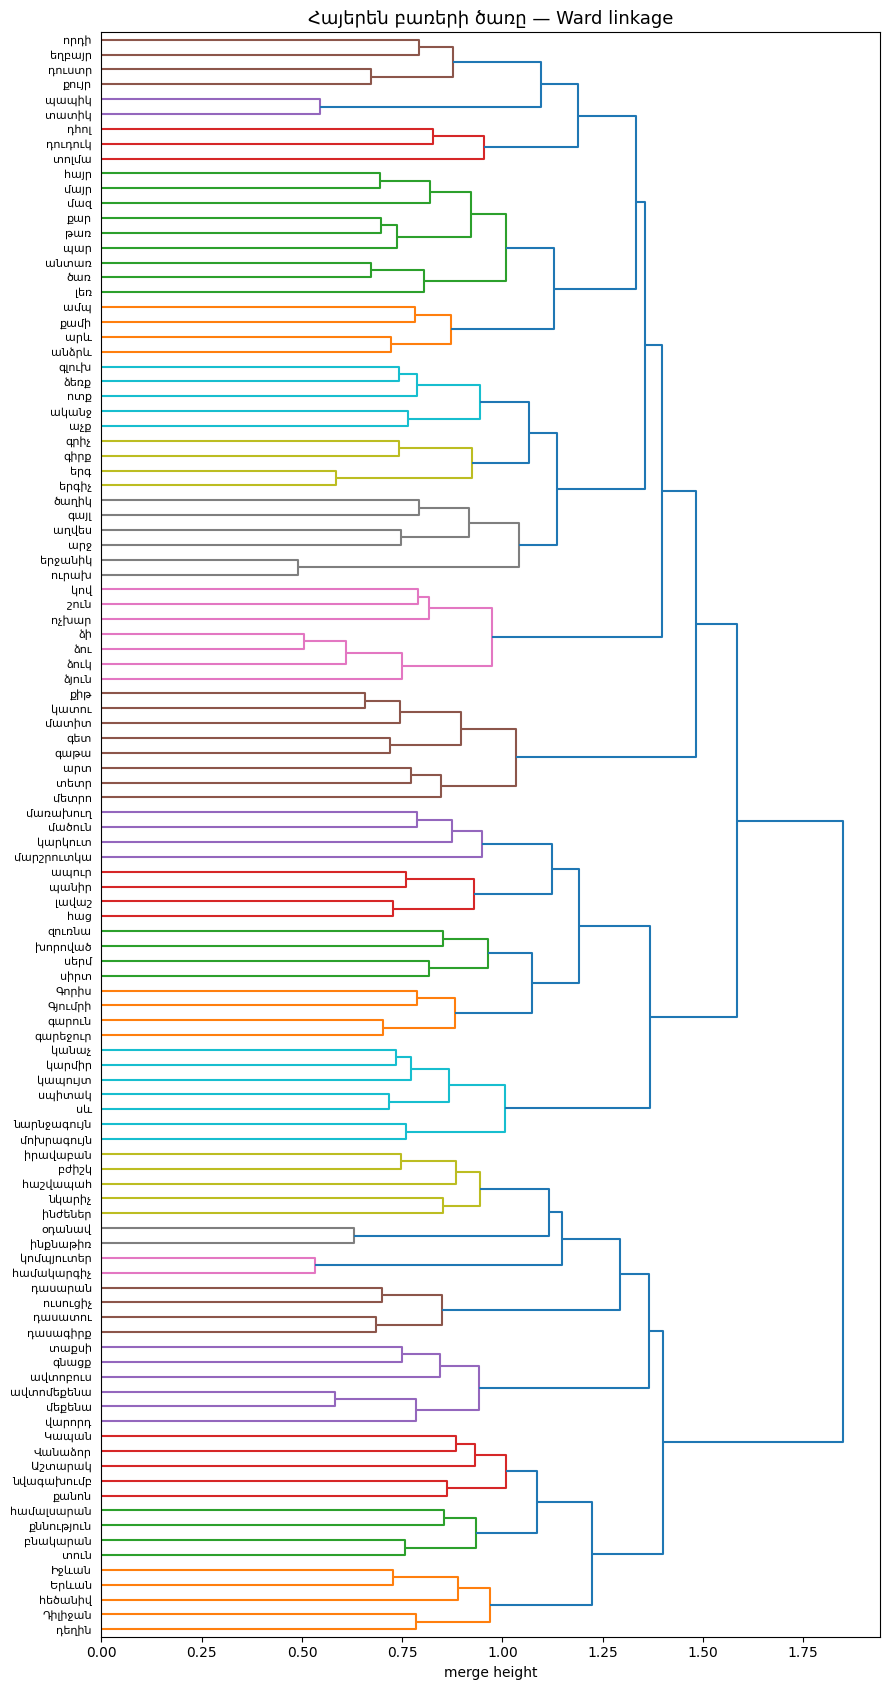

In [3]:
Z = linkage(X, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(9, 17))
dendrogram(Z, labels=words, orientation="right", ax=ax, leaf_font_size=8,
           color_threshold=1.05)
ax.set_title("Հայերեն բառերի ծառը — Ward linkage", fontsize=13)
ax.set_xlabel("merge height")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "st_tree_ward.png"), dpi=110, bbox_inches="tight")
plt.show()

Ընտանիքի բառերը՝ միասին։ Գույները՝ միասին։ Քաղաքները՝ միասին։ Այնքան լավ է, որ կարելի է
հանգիստ վստահել։

Family, colours and cities come out as clean blocks. Before scoring anything, notice that
`վարորդ` (driver) sits with **transport** rather than with the other professions - which is
arguably more correct than our own ground truth.

## 2. Predict first

Look at the word list. **Ո՞ր երկու բառն է ամենաշուտ միանալու** — which two words do you think
merge first, i.e. sit closest together in this space?

The honest guess is a synonym pair, or `տատիկ` + `պապիկ`. Now look.

### Երկու տարբեր «հեռավորություն» — two different distances

Ուշադրություն, սա հեշտ է շփոթել․ այստեղից սկսած երկու բան կարող ենք չափել, և դրանք **նույնը չեն**․

- **`dist(a, b)`** — երկու վեկտորների իրական Euclidean հեռավորությունը։ Սա **տարածության** մասին է։
- **`merge_height(a, b)`** — այն բարձրությունը, որի վրա ծառը առաջին անգամ նրանց նույն կլաստերում
  է հայտնվում։ Սա **ծառի** մասին է։

Երբ երկու բառ ուղղակի իրար հետ են միանում, երկու թիվը համընկնում են։ Բայց երբ բառը միանում է
արդեն մեծացած կլաստերի, նա ժառանգում է *այդ կլաստերի* բարձրությունը, ոչ թե իր հեռավորությունը։

The two agree when a pair merges directly with each other, and diverge sharply otherwise: a word
joining an already-large cluster inherits *that cluster's* merge height. Across all 5 778 pairs
here they correlate only **0.45**. The dendrogram is a **lossy summary** of the distance matrix,
and that correlation --- the *cophenetic correlation* --- is precisely the measure of how lossy.

Ամեն հարց ներքևում «որքա՞ն մոտ են այս երկու բառը» է, ուստի ամենուր օգտագործում ենք `dist`։


In [4]:
n = len(words)
POS = {w: i for i, w in enumerate(words)}

D_true = pdist(X, metric="euclidean")   # how far apart the two vectors actually are
D_merge = cophenet(Z)                   # how high up the tree they first meet


def _k(a, b):
    """Position of the pair (a, b) inside a condensed distance matrix."""
    i, j = sorted((POS[a], POS[b]))
    return n * i + j - ((i + 2) * (i + 1)) // 2


def dist(a, b):
    return D_true[_k(a, b)]


def merge_height(a, b):
    return D_merge[_k(a, b)]


print(f"cophenetic correlation (how faithfully the tree preserves real distances): "
      f"{np.corrcoef(D_true, D_merge)[0, 1]:.3f}\n")
print(f"{'pair':30s} {'true dist':>10s} {'merge height':>13s}")
for a, b in [("ուրախ", "երջանիկ"), ("ձու", "ձի"), ("ձի", "ձուկ"), ("ձի", "ձեռք")]:
    flag = "  <-- tree exaggerates" if merge_height(a, b) - dist(a, b) > 0.3 else ""
    print(f"  {a + ' + ' + b:28s} {dist(a, b):>10.3f} {merge_height(a, b):>13.3f}{flag}")

pairs = [(dist(words[i], words[j]), words[i], words[j])
         for i in range(n) for j in range(i + 1, n)]
pairs.sort()

print("\nthe ten closest pairs in the whole space:\n")
for h, a, b in pairs[:10]:
    same = "same family" if labels[words.index(a)] == labels[words.index(b)] else "DIFFERENT families"
    print(f"  {h:.3f}   {a:12s} + {b:12s}   ({same})")


cophenetic correlation (how faithfully the tree preserves real distances): 0.448

pair                            true dist  merge height
  ուրախ + երջանիկ                   0.490         0.490
  ձու + ձի                          0.505         0.505
  ձի + ձուկ                         0.627         0.611
  ձի + ձեռք                         0.793         1.399  <-- tree exaggerates

the ten closest pairs in the whole space:

  0.490   ուրախ        + երջանիկ        (same family)
  0.505   ձու          + ձի             (DIFFERENT families)
  0.532   համակարգիչ   + կոմպյուտեր     (same family)
  0.542   ձու          + ձուկ           (DIFFERENT families)
  0.546   տատիկ        + պապիկ          (same family)
  0.581   մեքենա       + ավտոմեքենա     (DIFFERENT families)
  0.586   երգիչ        + երգ            (DIFFERENT families)
  0.627   ձի           + ձուկ           (same family)
  0.629   ինքնաթիռ     + օդանավ         (DIFFERENT families)
  0.650   ձի           + ձյուն          (DIFFERENT 

`ձու` և `ձի`։ **Ձու և ձի** — an egg and a horse — 0.505, ամբողջ տարածության **երկրորդ**
ամենամոտ զույգը, և ամենամոտը նրանցից, որոնք ընտանիքի սահման են հատում։

Only one pair in the entire space is closer: `ուրախ`/`երջանիկ`, which is a planted synonym pair
and *supposed* to be close. An egg and a horse beat `տատիկ`/`պապիկ`, beat
`համակարգիչ`/`կոմպյուտեր`, and beat four of our six deliberate synonyms.

Ձուն ուտելիք է, ձին՝ կենդանի։ Իմաստային կապ չկա։

Եվ դա մեկ զույգ չէ։ Տասը ամենամոտ զույգերից **չորսը** `ձ`-ով սկսվող բառեր են՝ `ձու+ձի`,
`ձու+ձուկ`, `ձի+ձուկ`, `ձի+ձյուն`։ Չորս տեղ տասից, չորս բառից, որոնք ոչ մի իմաստային ընտանիք
չեն կիսում։

Look again at that top-ten list: **four of the ten closest pairs in the entire space** are
`ձ-` words --- ranks 2, 4, 8 and 10. Four slots out of ten, spent on four words that share no
semantic family at all.

Այս պահին ամեն ինչ պետք է կասկածելի թվա։

In [5]:
SYNONYMS = [tuple(p) for p in meta["synonym_pairs"]]

print("our planted synonym pairs, which SHOULD have been the closest things here:\n")
syn_h = []
for a, b, note in SYNONYMS:
    if a in words and b in words:
        h = dist(a, b)
        syn_h.append(h)
        print(f"  {h:.3f}   {a} + {b}   ({note})")

print(f"\nmedian synonym pair : {np.median(syn_h):.3f}")
print(f"ձու + ձի            : {dist('ձու', 'ձի'):.3f}   <-- closer than all but one of them")

our planted synonym pairs, which SHOULD have been the closest things here:

  0.581   մեքենա + ավտոմեքենա   (same thing, one is the fuller form)
  0.532   համակարգիչ + կոմպյուտեր   (native coinage vs loanword)
  0.629   ինքնաթիռ + օդանավ   (both aircraft)
  0.490   ուրախ + երջանիկ   (happy / joyful)
  0.758   տուն + բնակարան   (house / flat - close but not identical, a useful middle case)
  0.766   ուսուցիչ + դասատու   (teacher, two words in daily use)

median synonym pair : 0.605
ձու + ձի            : 0.505   <-- closer than all but one of them


## 3. Ձևակերպենք վարկած — form a hypothesis, then break it

Ակնհայտ բացատրությունը՝ **մոդելը նայում է ուղղագրությանը, ոչ թե իմաստին**։ `ձու`, `ձի`, `ձուկ`,
`ձյուն` — բոլորը սկսվում են `ձ`-ով։

The obvious explanation is that the model is reading **spelling**, not meaning. Every one of
those words starts with `ձ`.

It is a good hypothesis. It is also wrong, and the dataset contains its own refutation.

In [6]:
DZ = ["ձու", "ձի", "ձուկ", "ձյուն", "ձեռք"]
print("every word here begins with ձ. distances to ձի:\n")
for w in DZ:
    if w == "ձի":
        continue
    fam = labels[words.index(w)]
    print(f"  ձի + {w:8s}  {dist('ձի', w):.3f}   ({w} is in family '{fam}')")

every word here begins with ձ. distances to ձի:

  ձի + ձու       0.505   (ձու is in family 'ուտելիք')
  ձի + ձուկ      0.627   (ձուկ is in family 'կենդանիներ')
  ձի + ձյուն     0.650   (ձյուն is in family 'եղանակ')
  ձի + ձեռք      0.793   (ձեռք is in family 'մարմին')


`ձեռք` **նույնպես** սկսվում է `ձ`-ով, բայց ամենահեռուն է՝ 0.793։

`ձեռք` begins with the very same letter, yet sits further from `ձի` than any of the other three
--- **1.6×** the distance of `ձու`. So "the model groups by spelling" cannot be the rule: all five
words share the letter `ձ`, and one of them flatly refuses to join. Something separates `ձեռք`
from the other four, and it is not the alphabet.

## 4. Բացենք tokenizer-ը — open the tokenizer

Մոդելը բառեր չի տեսնում։ Այն տեսնում է **subword token-ներ**։

The model never sees a word. It sees **subword tokens**, and for a low-resource language those
tokens are small: vocabularies built mostly from English text chop Armenian into short fragments.
The RNN and RAG lectures later in the course measure this "Armenian tax" directly.

In [7]:
print("how the tokenizer actually sees these words:\n")
for w in DZ:
    print(f"  {w:8s} -> {TOKENS[w]}")

how the tokenizer actually sees these words:

  ձու      -> ['▁ձ', 'ու']
  ձի       -> ['▁ձ', 'ի']
  ձուկ     -> ['▁ձ', 'ուկ']
  ձյուն    -> ['▁ձ', 'յուն']
  ձեռք     -> ['▁ձեռք']


Ահա կանոնը։ `ձու`, `ձի`, `ձուկ`, `ձյուն` — բոլորը սկսվում են **նույն token-ով**՝ `▁ձ`։
`ձեռք`-ը մեկ ամբողջական token է՝ `▁ձեռք`, և ոչինչ չի կիսում մյուսների հետ։

**The rule is a shared subword token, not a shared letter.** Test it against every probe group
in the dataset - including the ones designed *not* to collide.

In [8]:
def informative(w):
    # "▁" alone is SentencePiece's word-boundary marker - it carries no information,
    # and dropping it is the difference between a rule that works and one that does not.
    return {t for t in TOKENS[w] if t != "▁"}


print(f"median distance over all {len(D_true):,} pairs in the dataset: {np.median(D_true):.3f}\n")
print(f"{'group':28s} {'shared token':14s} {'median dist':>11s}   verdict")
for g in meta["ortho_probes"]:
    ws = [w for w in g["words"] if w in words]
    shared = set.intersection(*(informative(w) for w in ws))
    hs = [dist(ws[i], ws[j]) for i in range(len(ws)) for j in range(i + 1, len(ws))]
    verdict = "COLLIDES" if shared else "stays apart"
    print(f"{g['name']:28s} {(sorted(shared)[0] if shared else '-'):14s} "
          f"{np.median(hs):>11.3f}   {verdict}")

median distance over all 5,778 pairs in the dataset: 0.934

group                        shared token   median dist   verdict
ձ-                           ▁ձ                   0.639   COLLIDES
ձեռք (the control for ձ-)    -                    0.793   stays apart
գար-                         գար                  0.703   COLLIDES
ար- (control)                -                    0.784   stays apart
ք- (control)                 -                    0.852   stays apart
մա- (control)                -                    0.845   stays apart


Կանոնն աշխատում է վեց խմբի վրա էլ։ Token կիսողները մոտ են, միայն տառ կիսողները՝ ոչ։

The rule holds across all six groups. The two that share a **token** sit at 0.64 and 0.70; the
three that share only an opening **letter** sit at 0.78, 0.85 and 0.85.

Մի ազնիվ դիտողություն. control-ները նույնպես միջինից մոտ են (0.78-0.85 ընդդեմ ամբողջ
հավաքածուի 0.93 մեդիանի)։ Դա սպասելի է — բոլորն էլ կարճ, հաճախադեպ բառեր են։ Կարևորը
**բացվածքն է** token-կիսողների և տառ-կիսողների միջև, ոչ թե բացարձակ թիվը.

## 5. Ի՞նչ արժե դա — quantify the damage

Վեց բառ 99-ից։ Որքա՞ն է դա արժենում։

In [9]:
fam_names = list(FAMILIES)
in_family = np.array([l in fam_names for l in labels])
y = np.array([fam_names.index(l) if l in fam_names else -1 for l in labels])
K = len(FAMILIES)


def score(mask, tag):
    Zs = linkage(X[mask], method="ward")
    pred = fcluster(Zs, t=K, criterion="maxclust")
    a = adjusted_rand_score(y[mask], pred)
    m = adjusted_mutual_info_score(y[mask], pred)
    print(f"  {tag:44s} ARI {a:.3f}   AMI {m:.3f}")
    return a


COLLIDING = {"ձու", "ձի", "ձուկ", "ձյուն", "գարուն", "գարեջուր"}
keep_all = in_family
keep_clean = in_family & np.array([w not in COLLIDING for w in words])

a_all = score(keep_all, f"all {keep_all.sum()} family words")
a_clean = score(keep_clean, f"minus the {len(COLLIDING)} token-colliding words")
print(f"\n  {len(COLLIDING)} words - {len(COLLIDING)/keep_all.sum():.0%} of the data - "
      f"removing them lifts the ARI by {(a_clean - a_all)/a_all:.0%}")

  all 99 family words                          ARI 0.287   AMI 0.415
  minus the 6 token-colliding words            ARI 0.350   AMI 0.487

  6 words - 6% of the data - removing them lifts the ARI by 22%


### Ամենապարզ թեստը — the simplest possible test

ARI-ն 0.287 է։ Դա շա՞տ է, թե՞ քիչ։ Անկեղծ պատասխանը՝ դժվար է զգալ։ Ուրեմն հարցնենք ավելի պարզ
բան, որի պատասխանը կարելի է *կարդալ*.

> **Ամեն բառի ամենամոտ հարևանը իր ընտանիքի՞ց է։**

ARI is 0.287. Is that good? Honestly, it is hard to have an intuition for. So ask something a
human can check by eye instead: **for each word, is its single nearest neighbour in the same
family?** No clustering, no `k`, no linkage --- just the space itself, asked the simplest question
it can answer.

Կանխատեսեք թիվը, նախքան նայելը։ Predict the number before you look.


In [10]:
S = X @ X.T                          # cosine similarity - the vectors are unit norm
np.fill_diagonal(S, -np.inf)
fam_idx = np.where(in_family)[0]

hits, misses = 0, []
for i in fam_idx:
    nn = fam_idx[np.argsort(-S[i, fam_idx])][0]
    if labels[nn] == labels[i]:
        hits += 1
    else:
        misses.append((float(S[i, nn]), words[i], labels[i], words[nn], labels[nn]))

print(f"nearest neighbour is in the same family: {hits}/{len(fam_idx)} = {hits / len(fam_idx):.1%}")
print(f"(random guessing would give about {1 / len(fam_names):.0%})\n")

misses.sort(reverse=True)
print("the twelve most confident mistakes:\n")
for s, w, l, nw, nl in misses[:12]:
    shared = informative(w) & informative(nw)
    tag = f"   <-- shares {sorted(shared)}" if shared else ""
    print(f"  {s:.3f}  {w:11s} ({l:18s}) -> {nw:11s} ({nl:18s}){tag}")

print("\nthe rest of the list, most confident first (* = shares a token):\n")
tail = [f"{w}->{nw}" + ("*" if informative(w) & informative(nw) else "")
        for s, w, l, nw, nl in misses[12:]]
for i in range(0, len(tail), 6):
    print("  " + "   ".join(tail[i:i + 6]))

tok_all = sum(1 for s, w, l, nw, nl in misses if informative(w) & informative(nw))
tok_top = sum(1 for s, w, l, nw, nl in misses[:6] if informative(w) & informative(nw))
print(f"\ntoken collisions account for {tok_top}/6 of the most confident mistakes, "
      f"but only {tok_all}/{len(misses)} of all of them")


nearest neighbour is in the same family: 51/99 = 51.5%
(random guessing would give about 8%)

the twelve most confident mistakes:

  0.872  ձու         (ուտելիք           ) -> ձի          (կենդանիներ        )   <-- shares ['▁ձ']
  0.872  ձի          (կենդանիներ        ) -> ձու         (ուտելիք           )   <-- shares ['▁ձ']
  0.853  ձուկ        (կենդանիներ        ) -> ձու         (ուտելիք           )   <-- shares ['▁ձ']
  0.828  երգիչ       (մասնագիտություններ) -> երգ         (երաժշտություն     )   <-- shares ['▁երգ']
  0.828  երգ         (երաժշտություն     ) -> երգիչ       (մասնագիտություններ)   <-- shares ['▁երգ']
  0.789  ձյուն       (եղանակ            ) -> ձի          (կենդանիներ        )   <-- shares ['▁ձ']
  0.783  քիթ         (մարմին            ) -> կատու       (կենդանիներ        )
  0.783  կատու       (կենդանիներ        ) -> քիթ         (մարմին            )
  0.757  մատիտ       (դպրոց             ) -> քիթ         (մարմին            )
  0.757  քար         (բնություն         ) -

**Կեսը։** Մետաղադրամի նետում, 12 ընտանիքի դեպքում, որտեղ պատահականը 8% կլիներ։

Half. On a task where random guessing scores about 8 %, a 1024-dimensional model fine-tuned for
Armenian puts the nearest neighbour in the right family barely half the time. That is the same
result ARI was reporting, in a form you can argue with.

Բայց ամենակարևորը սխալների **ցուցակն է**։ But the real payload is the list, and it says something
more precise than section 4 did:

- **Ամենավստահ սխալները token-ի բախումներ են։** The six most confident mistakes in the whole
  dataset --- `ձու`/`ձի`, `ձուկ`/`ձու`, `երգիչ`/`երգ`, `ձյուն`/`ձի` --- *all six* share a subword
  token. When this model is most sure, and wrong, a tokenizer collision is why.
- **Բայց դա սխալների մեծամասնությունը չէ։** Only 10 of the 48 failures involve a shared token.
  The long tail is different: `կատու`→`քիթ`, `մատիտ`→`քիթ`, `թառ`→`քար` near the top, and
  `Կապան`→`կապույտ`, `քանոն`→`կանաչ`, `մետրո`→`տետր` further down. These share no token at all --- they merely *look and sound*
  alike, and that is apparently enough.

Այսինքն՝ 4-րդ բաժնի կանոնը ճիշտ է, բայց ոչ ամբողջական։ So the rule from section 4 is right about
what it tested and incomplete about the rest: shared tokens produce the **worst** confusions,
while general orthographic similarity produces the **most**. The probe groups were designed to
isolate the first effect, and a designed probe can only ever confirm the thing it was designed to
isolate. The failure list is where the undesigned effects show up.


## 6. Օգնո՞ւմ է համատեքստը — does context repair it?

Sentence encoder-ը սովորել է **նախադասությունների** վրա, ոչ թե առանձին բառերի։ Ի՞նչ կլինի, եթե
նույն բառը տանք կարճ արտահայտության մեջ՝ `ձու` → `հավի ձու`։

In [11]:
pw = list(d["phrase_words"])
ph = list(d["phrases"])
Xp = d["X_phrase"]
idx = {w: i for i, w in enumerate(pw)}

print(f"{'pair':26s} {'as word':>8s} {'as phrase':>10s}")
better = 0
rows = []
for g in meta["ortho_probes"]:
    ws = [w for w in g["words"] if w in idx]
    for i in range(len(ws)):
        for j in range(i + 1, len(ws)):
            a, b = idx[ws[i]], idx[ws[j]]
            cw = float(X[words.index(ws[i])] @ X[words.index(ws[j])])
            cp = float(Xp[a] @ Xp[b])
            rows.append((ws[i], ws[j], cw, cp))
            better += cp < cw
for a, b, cw, cp in rows:
    print(f"  {a + ' + ' + b:24s} {cw:>8.3f} {cp:>10.3f}"
          f"{'   closer' if cp > cw else ''}")
print(f"\n{better} of {len(rows)} pairs moved apart once given context")
print(f"\nexample: {ph[idx['ձու']]!r} vs {ph[idx['ձի']]!r}")

pair                        as word  as phrase
  ձու + ձի                    0.872      0.709
  ձու + ձուկ                  0.853      0.695
  ձու + ձյուն                 0.783      0.617
  ձի + ձուկ                   0.803      0.640
  ձի + ձյուն                  0.789      0.604
  ձուկ + ձյուն                0.712      0.571
  ձեռք + ձի                   0.685      0.581
  գարուն + գարեջուր           0.753      0.551
  արջ + արև                   0.693      0.511
  արջ + արտ                   0.713      0.573
  արև + արտ                   0.608      0.446
  քար + քամի                  0.604      0.609   closer
  քար + քիթ                   0.639      0.598
  քամի + քիթ                  0.637      0.584
  մայր + մածուն               0.655      0.543
  մայր + մատիտ                0.641      0.564
  մածուն + մատիտ              0.643      0.565

16 of 17 pairs moved apart once given context

example: 'հավի ձու' vs 'արագ ձի'


Համատեքստը օգնում է, բայց չի լուծում։ Context helps - almost every pair separates - but it is a
**mitigation, not a cure**. Score the whole tree using phrases wherever we have them:

In [12]:
X_mixed = X.copy()
for w in pw:
    X_mixed[words.index(w)] = Xp[idx[w]]

Zm = linkage(X_mixed[in_family], method="ward")
pred = fcluster(Zm, t=K, criterion="maxclust")
a_phrase = adjusted_rand_score(y[in_family], pred)
print(f"  bare words                        ARI {a_all:.3f}")
print(f"  phrases where available ({len(pw)}/{in_family.sum()})  ARI {a_phrase:.3f}")
print(f"  deleting the offenders instead    ARI {a_clean:.3f}")
print("\nContext recovers roughly half of what the collisions cost.")

  bare words                        ARI 0.287
  phrases where available (23/99)  ARI 0.321
  deleting the offenders instead    ARI 0.350

Context recovers roughly half of what the collisions cost.


## 7. Euclidean թե՞ cosine

Ընդունված է կարծել, որ սա կարևոր ընտրություն է։ Նորմալացված վեկտորների համար՝

$$\|a-b\|^2 = \|a\|^2 + \|b\|^2 - 2\,a\cdot b = 2 - 2\cos(a,b)$$

Այսինքն՝ Euclidean-ը cosine-ի **մոնոտոն ֆունկցիա** է։ Ստուգենք։

In [13]:
de = pdist(X, metric="euclidean")
dc = pdist(X, metric="cosine")

print(f"max |d_euclid^2 - (2 - 2cos)| = {np.abs(de**2 - 2*dc).max():.2e}")
print(f"rank correlation of the two distance matrices = "
      f"{np.corrcoef(de.argsort().argsort(), dc.argsort().argsort())[0,1]:.6f}")

max |d_euclid^2 - (2 - 2cos)| = 2.23e-07
rank correlation of the two distance matrices = 1.000000


Նույն դասավորությունն է (2.23e-07-ը float32-ի ճշտությունն է, ոչ թե իրական տարբերություն)։
Ուրեմն ո՞ր linkage-ները կարող են ընդհանրապես փոխվել։

* **Single** և **complete** նայում են միայն հեռավորությունների **հերթականությանը**։
  Հերթականությունը նույնն է → արդյունքը *չի կարող* փոխվել։ Սա ապացույց է, ոչ թե դիտարկում։
* **Average**-ը միջինացնում է **արժեքները**, ոչ թե դասակարգերը → սկզբունքորեն կարող է փոխվել։

Ստուգենք մի քանի `k`-ի վրա, ոչ թե մեկի։

In [14]:
print("ARI between the euclidean and cosine partitions, at several k:\n")
print(f"  {'k':>3}  " + "  ".join(f"{m:>9s}" for m in ("single", "complete", "average")))
for k in (2, 3, 5, 8, 12, 16, 20, 30):
    row = []
    for method in ("single", "complete", "average"):
        pe = fcluster(linkage(de, method=method), t=k, criterion="maxclust")
        pc = fcluster(linkage(dc, method=method), t=k, criterion="maxclust")
        row.append(f"{adjusted_rand_score(pe, pc):9.4f}")
    print(f"  {k:>3}  " + "  ".join(row))

Ze, Zc = linkage(de, method="average"), linkage(dc, method="average")
print(f"\naverage linkage, merge ORDER identical? {np.array_equal(Ze[:, :2], Zc[:, :2])}")

ARI between the euclidean and cosine partitions, at several k:

    k     single   complete    average
    2     1.0000     1.0000     1.0000
    3     1.0000     1.0000     1.0000
    5     1.0000     1.0000     1.0000
    8     1.0000     1.0000     1.0000
   12     1.0000     1.0000     1.0000
   16     1.0000     1.0000     0.9877
   20     1.0000     1.0000     1.0000
   30     1.0000     1.0000     1.0000

average linkage, merge ORDER identical? False


Single և complete՝ **1.0000 ամեն `k`-ի վրա**, ինչպես և պետք է լիներ։

Average-ի դեպքում միացումների **հերթականությունը իրոք տարբեր է**, բայց տարբերությունը այնքան
փոքր է, որ վերջնական բաժանումը գրեթե միշտ նույնն է ստացվում — `k = 16`-ի դեպքում հազիվ երևում է։

So the theory holds exactly where it promises to, and the one case where cosine *can* change
your answer turns out to change it barely at all. Worth knowing before you spend an afternoon
agonising over the choice.

## 8. Ward և cosine

Իսկ Ward-ը սահմանված է **միայն** Euclidean-ի համար — այն նվազեցնում է ներկլաստերային
քառակուսային շեղումը, ինչը իմաստ ունի միայն այնտեղ։

Ward is defined only for Euclidean. Watch what `scipy` does about that:

In [15]:
try:
    linkage(X, method="ward", metric="cosine")
    print("  linkage(X, method='ward', metric='cosine')      -> allowed")
except ValueError as e:
    print(f"  linkage(X, method='ward', metric='cosine')      -> REFUSED: {e}")

Zbad = linkage(dc, method="ward")     # same request, precomputed distances
print(f"  linkage(pdist(X,'cosine'), method='ward')       -> ran silently, "
      f"{Zbad.shape[0]} merges")
print("\nThe guardrail exists, and passing a precomputed matrix walks straight around it.")

  linkage(X, method='ward', metric='cosine')      -> REFUSED: `method=ward` requires the distance metric to be Euclidean
  linkage(pdist(X,'cosine'), method='ward')       -> ran silently, 107 merges

The guardrail exists, and passing a precomputed matrix walks straight around it.


## 9. Linkage-ի ընտրությունը

Metric-ը գրեթե ոչինչ չփոխեց։ Linkage-ը փոխում է ամեն ինչ։

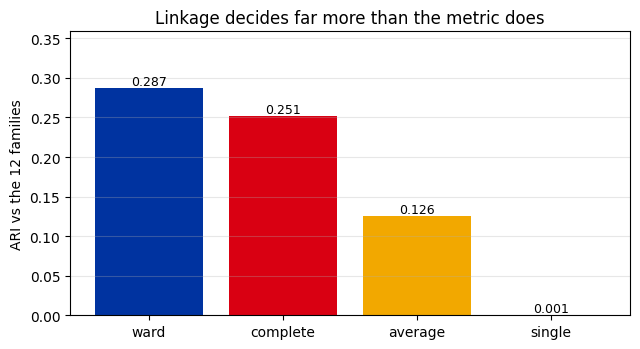

  ward      ARI 0.287   AMI 0.415
  complete  ARI 0.251   AMI 0.394
  average   ARI 0.126   AMI 0.326
  single    ARI 0.001   AMI 0.001


In [16]:
res = {}
for method in ("ward", "complete", "average", "single"):
    Zi = linkage(X[in_family], method=method)
    pred = fcluster(Zi, t=K, criterion="maxclust")
    res[method] = (adjusted_rand_score(y[in_family], pred),
                   adjusted_mutual_info_score(y[in_family], pred))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ms = list(res)
bars = ax.bar(ms, [res[m][0] for m in ms], color=[ARM_BLUE, ARM_RED, ARM_ORANGE, "#999999"])
ax.bar_label(bars, fmt="%.3f", fontsize=9)
ax.set(ylabel="ARI vs the 12 families", title="Linkage decides far more than the metric does")
ax.set_ylim(0, max(v[0] for v in res.values()) * 1.25)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "st_linkage.png"), dpi=120, bbox_inches="tight")
plt.show()

for m in ms:
    print(f"  {m:9s} ARI {res[m][0]:.3f}   AMI {res[m][1]:.3f}")

Single linkage-ը փլուզվում է — chaining, ինչպես դասախոսության մեջ էր։ Ward-ը հաղթում է, որովհետև
մեր ընտանիքները մոտավորապես հավասար չափի, կլորավուն խմբեր են, ինչը հենց Ward-ի ենթադրությունն է։

### Ո՞ր ընտանիքն է մոդելը իրականում պահում

Մինչ այժմ 12 ընտանիքը մեկ միավոր էինք համարում։ Բայց նրանք հավասար չեն։ Չափենք ամեն ընտանիքի
**ներքին** նմանությունը և համեմատենք նրա ամենամոտ **մրցակցի** հետ։

We have been treating the 12 families as one lump. They are not equal. For each family, compare
how similar its words are **to each other** against how similar they are to the nearest *rival*
family. The margin between those two numbers is how much room the clustering has to work with.


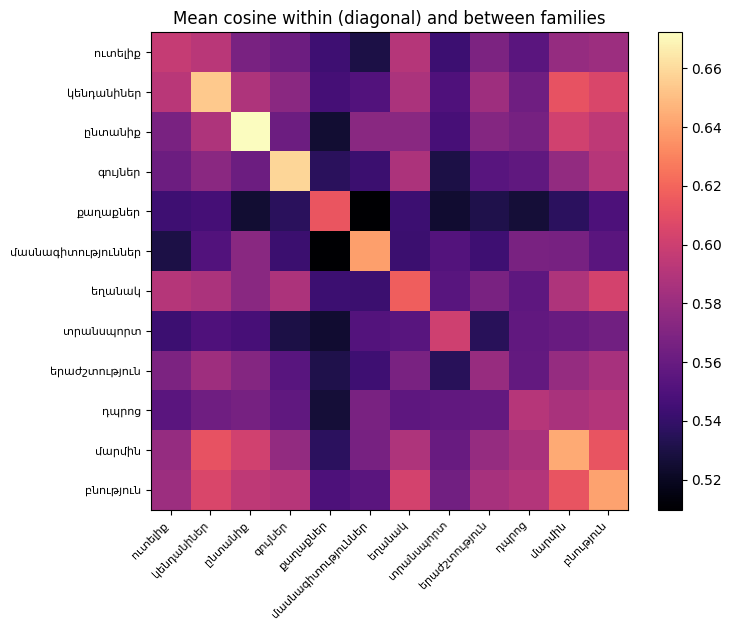

family                   self  closest rival           rival   margin
ընտանիք                 0.672  մարմին                  0.601   +0.071
գույներ                 0.659  բնություն               0.591   +0.067
մասնագիտություններ      0.639  ընտանիք                 0.573   +0.066
քաղաքներ                0.614  բնություն               0.549   +0.065
կենդանիներ              0.654  մարմին                  0.612   +0.042
տրանսպորտ               0.601  բնություն               0.564   +0.037
մարմին                  0.643  բնություն               0.613   +0.030
բնություն               0.641  մարմին                  0.613   +0.028
եղանակ                  0.618  բնություն               0.603   +0.015
ուտելիք                 0.597  կենդանիներ              0.592   +0.005
դպրոց                   0.592  բնություն               0.590   +0.002
երաժշտություն           0.579  բնություն               0.585   -0.006   <-- not held together

բնություն is the closest rival for 7 of the 12 families


In [17]:
M = np.zeros((K, K))
for a, fa in enumerate(fam_names):
    ma = np.array([l == fa for l in labels])
    for b, fb in enumerate(fam_names):
        mb = np.array([l == fb for l in labels])
        blk = X[ma] @ X[mb].T
        M[a, b] = ((blk.sum() - np.trace(blk)) / (ma.sum() * (ma.sum() - 1))
                   if a == b else blk.mean())

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(M, cmap="magma")
ax.set_xticks(range(K), fam_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(K), fam_names, fontsize=8)
ax.set_title("Mean cosine within (diagonal) and between families")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "st_family_heatmap.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"{'family':22s} {'self':>6s}  {'closest rival':22s} {'rival':>6s} {'margin':>8s}")
rows = []
for a, fa in enumerate(fam_names):
    v, r = max((M[a, b], fam_names[b]) for b in range(K) if b != a)
    rows.append((M[a, a] - v, fa, M[a, a], r, v))
for margin, fa, self_s, rival, rival_s in sorted(rows, reverse=True):
    flag = "   <-- not held together" if margin <= 0 else ""
    print(f"{fa:22s} {self_s:6.3f}  {rival:22s} {rival_s:6.3f} {margin:+8.3f}{flag}")

rival_counts = {}
for _, _, _, rival, _ in rows:
    rival_counts[rival] = rival_counts.get(rival, 0) + 1
top = max(rival_counts.items(), key=lambda kv: kv[1])
print(f"\n{top[0]} is the closest rival for {top[1]} of the {K} families")


Երկու բան դուրս է գալիս այս աղյուսակից։

**Ընտանիքները հավասար չեն։** `ընտանիք` և `գույներ` ամուր են (+0.071, +0.067)։ `երաժշտություն`-ը
**բացասական** մարժա ունի՝ նրա բառերը միջինում ավելի մոտ են `բնություն`-ին, քան իրար։

The families are not equally real. `ընտանիք` and `գույներ` hold together comfortably. But
`երաժշտություն` has a **negative** margin: its words are on average closer to `բնություն` than to
each other. And it is not a modelling failure so much as an honest one --- look at what we put in
that family. `դուդուկ`, `զուռնա`, `թառ` and `քանոն` are objects; `երգ` and `պար` are activities;
`նվագախումբ` is a group of people. "Music" is *our* category, imposed on things a spectrum of
usage does not group together. `դպրոց` (+0.002) and `ուտելիք` (+0.005) have the same problem.

**`բնություն`-ը դարակ է, ոչ թե ընտանիք.** it is the closest rival for **7 of the 12** families.

That is the same shape as the *junk drawer* cluster in the photo-clustering project of chapter 10
(dimensionality reduction), and it appears for the same reason: a category broad enough to be adjacent to everything
sits in the middle of the space, and everything's nearest wrong answer is whatever is nearest the
middle. Whenever one cluster or class is everybody's second choice, suspect that it is not a
category at all --- it is the absence of one.

Եվ ահա ամենակարևոր հետևանքը։ **Այս մարժաներից ոչ մեկը հաշվելի չէ առանց պիտակների։** Not one of
these numbers is computable without the labels. In real unsupervised work you would never learn
that `երաժշտություն` was hopeless from the start --- you would just get a bad cluster and have to
guess whether the algorithm or the category was at fault.


## 10. Բազմիմաստություն — one word, several meanings

Հայերենում `Արա`-ն երեք բան է՝ **թագավոր** (Արա Գեղեցիկ), **դիմելաձև** (արա, այ տղա), և
**հրամայական** (արա քո գործը)։

Կարո՞ղ է մոդելը տարբերել դրանք։ Յուրաքանչյուր իմաստի համար ունենք նախադասություն և առանձին
խարիսխ-նախադասություն։

In [18]:
poly_texts = list(d["poly_texts"])
Xpoly = d["X_poly"]
rows = meta["poly_rows"]

by_form = {}
for r in rows:
    by_form.setdefault(r["form"], []).append(r)

total, hits = 0, 0
for form, rs in by_form.items():
    print(f"\n{form}:")
    for r in rs:
        sims = [(o["sense"], float(Xpoly[r["text_idx"]] @ Xpoly[o["anchor_idx"]]))
                for o in rs]
        pick, _ = max(sims, key=lambda t: t[1])
        ok = pick == r["sense"]
        hits += ok
        total += 1
        detail = "  ".join(f"{s}={v:.3f}" for s, v in sims)
        print(f"   {r['sense']:14s} -> {pick:14s} {'✓' if ok else '✗'}   {detail}")
print(f"\n{hits}/{total} senses matched their own anchor")


Արա:
   թագավոր        -> թագավոր        ✓   թագավոր=0.614  դիմելաձև=0.315  հրամայական=0.265
   դիմելաձև       -> հրամայական     ✗   թագավոր=0.300  դիմելաձև=0.382  հրամայական=0.387
   հրամայական     -> հրամայական     ✓   թագավոր=0.351  դիմելաձև=0.349  հրամայական=0.483

սեր:
   զգացմունք      -> զգացմունք      ✓   զգացմունք=0.661  կաթնամթերք=0.336
   կաթնամթերք     -> զգացմունք      ✗   զգացմունք=0.483  կաթնամթերք=0.426

մարտ:
   ամիս           -> ամիս           ✓   ամիս=0.636  ճակատամարտ=0.366
   ճակատամարտ     -> ամիս           ✗   ամիս=0.581  ճակատամարտ=0.497

բաց:
   բացված         -> բացված         ✓   բացված=0.561  գույնի երանգ=0.421
   գույնի երանգ   -> գույնի երանգ   ✓   բացված=0.415  գույնի երանգ=0.514

6/9 senses matched their own anchor


Երեքը սխալ։ Բայց նայեք **ո՞ր** երեքը՝ `դիմելաձև`, `կաթնամթերք`, `ճակատամարտ`։

Every failure is the **rarer** sense losing to the **dominant** one. `մարտ` as a battle loses
to `մարտ` the month; `սեր` as cream loses to `սեր` as love. The model has one prototype per
surface form, and context is not enough to pull the minority reading out of it.

In [19]:
print("how far the winning sense won by, in each case:\n")
for form, rs in by_form.items():
    for r in rs:
        sims = sorted(((o["sense"], float(Xpoly[r["text_idx"]] @ Xpoly[o["anchor_idx"]]))
                       for o in rs), key=lambda t: -t[1])
        gap = sims[0][1] - sims[1][1]
        ok = sims[0][0] == r["sense"]
        print(f"  {form:6s} {r['sense']:14s} {'✓' if ok else '✗'}  "
              f"won by {gap:+.3f}" + ("" if ok else f"  (true sense lost by {gap:.3f})"))

how far the winning sense won by, in each case:

  Արա    թագավոր        ✓  won by +0.299
  Արա    դիմելաձև       ✗  won by +0.005  (true sense lost by 0.005)
  Արա    հրամայական     ✓  won by +0.132
  սեր    զգացմունք      ✓  won by +0.326
  սեր    կաթնամթերք     ✗  won by +0.057  (true sense lost by 0.057)
  մարտ   ամիս           ✓  won by +0.270
  մարտ   ճակատամարտ     ✗  won by +0.084  (true sense lost by 0.084)
  բաց    բացված         ✓  won by +0.140
  բաց    գույնի երանգ   ✓  won by +0.100


## Bonus — ինչո՞ւ են բոլոր թվերը իրար մոտ

Նկատեցի՞ք, որ վերևի բոլոր նմանությունները 0.25-0.66 միջակայքում են, և ոչ մեկը բացասական չէ։
Դա պատահական չէ։

Transformer embedding տարածությունները **անիզոտրոպ** են՝ բոլոր վեկտորները մոտավորապես նույն
ուղղությամբ են նայում։ Չափենք, և տեսնենք՝ արդյոք դա է խնդիրը։

In [20]:
off = np.triu_indices(len(Xpoly), 1)
raw = (Xpoly @ Xpoly.T)[off]


def normed(A):
    return A / np.linalg.norm(A, axis=1, keepdims=True)


def poly_accuracy(M):
    h = 0
    for form, rs in by_form.items():
        for r in rs:
            sims = [(o["sense"], float(M[r["text_idx"]] @ M[o["anchor_idx"]])) for o in rs]
            h += max(sims, key=lambda t: t[1])[0] == r["sense"]
    return h


print(f"||mean vector|| over the polysemy texts : {np.linalg.norm(Xpoly.mean(0)):.3f}"
      f"   (0 would be isotropic)")
print(f"pairwise cosine, raw : mean {raw.mean():+.3f}  "
      f"range {raw.min():+.3f}..{raw.max():+.3f}\n")

# Which mean should you subtract? The choice matters, and it is easy to fool yourself.
for name, mu in [("no centering", None),
                 ("centre on the polysemy texts", Xpoly.mean(0)),
                 ("centre on the 108 word vectors", X.mean(0)),
                 ("centre on everything", np.vstack([X, Xpoly]).mean(0))]:
    M = Xpoly if mu is None else normed(Xpoly - mu)
    c = (M @ M.T)[off]
    print(f"  {name:32s} {poly_accuracy(M)}/{total}   "
          f"cosine range {c.min():+.3f}..{c.max():+.3f}")

||mean vector|| over the polysemy texts : 0.647   (0 would be isotropic)
pairwise cosine, raw : mean +0.385  range +0.249..+0.661

  no centering                     6/9   cosine range +0.249..+0.661
  centre on the polysemy texts     7/9   cosine range -0.235..+0.391
  centre on the 108 word vectors   6/9   cosine range +0.023..+0.562
  centre on everything             6/9   cosine range -0.040..+0.525


Անիզոտրոպությունը իրական է. միջին վեկտորի երկարությունը 0.65 է, և centering-ից հետո
նմանությունների միջակայքը բացվում է։ Բայց բազմիմաստության արդյունքը գրեթե չի փոխվում։

So: the anisotropy is real and centering genuinely spreads the similarities out - but it moves
the polysemy score by at most one case, and only when you centre on the polysemy texts
themselves, which is the smallest and least honest sample available.

**Անիզոտրոպությունը խնդիր է, բայց ոչ *այս* խնդիրը։** The thing breaking polysemy is the
dominant-sense prototype, and no amount of re-centering will fix that - it needs a model that
represents a word differently depending on its sentence.

## Եզրակացություն — conclusion

1. Ներկայացումը ֆիքսված էր, և միևնույն է՝ արդյունքը որոշվեց ուրիշ բաներով։
2. **Tokenizer-ը** ամենաուժեղն էր. վեց բառ, որոնք կիսում են subword token, և նրանց հեռացնելը
   ARI-ն բարձրացնում է ~22%-ով։ `ձու` և `ձի` ամբողջ տարածության երկրորդ ամենամոտ զույգն են, և
   ամենամոտը նրանցից, որոնք ընտանիքի սահման են հատում։ Սա հատուկ հայերենի խնդիր է՝
   ցածրռեսուրս լեզուն ավելի մանր է կտրատվում։
3. **Metric-ը** գրեթե ոչինչ չփոխեց (rank correlation 1.000000), իսկ **linkage-ը** փոխեց ամեն ինչ։
4. Համատեքստը՝ կարճ արտահայտությունը բառի փոխարեն, վերականգնում է կորուստի մոտ կեսը։
5. Բազմիմաստության դեպքում մոդելը ընտրում է **գերիշխող իմաստը**. `մարտ`-ը ամիս է, ոչ թե
   ճակատամարտ։ Centering-ը դա չի ուղղում։

The lesson generalises past Armenian: whenever a clustering result looks like it is about
meaning, check whether it is about the tokenizer first.